Training started...
Epoch 0, Loss: 4.7070
Epoch 1000, Loss: 0.0572
Epoch 2000, Loss: 0.0403
Epoch 3000, Loss: 0.0355
Epoch 4000, Loss: 0.0341


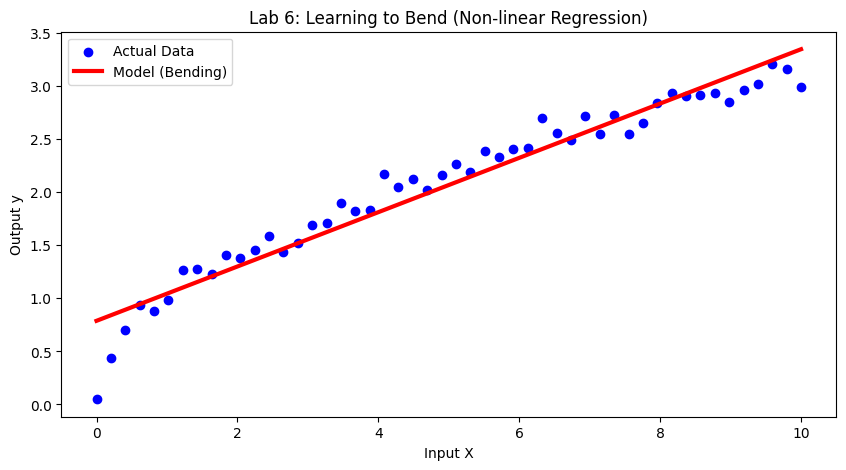

Final Loss: 0.0336


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- STEP 1: Create a Simple Non-Linear Dataset ---
# Ek aisa dataset jahan growth shuru mein fast hai aur baad mein slow (curve)
np.random.seed(42)
X = np.linspace(0, 10, 50).reshape(-1, 1) # 50 samples between 0 and 10
y = np.sqrt(X) + np.random.normal(0, 0.1, X.shape) # Non-linear target

# --- STEP 2: Initialize Parameters for a 2-Layer Network ---
# Structure: Input (1) -> Hidden (10) -> Output (1)
input_dim = 1
hidden_dim = 10
output_dim = 1

# Random initialization
W1 = np.random.randn(input_dim, hidden_dim) * 0.1
b1 = np.zeros((1, hidden_dim))
W2 = np.random.randn(hidden_dim, output_dim) * 0.1
b2 = np.zeros((1, output_dim))

# --- STEP 3: Activation Function (ReLU) ---
# Yeh model ko "bend" hone mein madad karta hai
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

# --- STEP 4: Training Loop (Forward & Backward Pass) ---
learning_rate = 0.001
epochs = 5000
loss_history = []

print("Training started...")
for epoch in range(epochs):
    # --- Forward Pass ---
    z1 = X @ W1 + b1
    h = relu(z1) # Intermediate representation
    y_hat = h @ W2 + b2

    # --- Compute Loss (MSE) ---
    error = y_hat - y
    loss = np.mean(error**2)
    loss_history.append(loss)

    # --- Backward Pass (Gradients) ---
    # Output layer gradients
    dL_dy_hat = 2 * error / len(X)
    dL_dW2 = h.T @ dL_dy_hat
    dL_db2 = np.sum(dL_dy_hat, axis=0, keepdims=True)

    # Hidden layer gradients (Chain Rule)
    dL_dh = dL_dy_hat @ W2.T
    dL_dz1 = dL_dh * relu_derivative(z1)
    dL_dW1 = X.T @ dL_dz1
    dL_db1 = np.sum(dL_dz1, axis=0, keepdims=True)

    # --- Update Parameters (Gradient Descent) ---
    W2 -= learning_rate * dL_dW2
    b2 -= learning_rate * dL_db2
    W1 -= learning_rate * dL_dW1
    b1 -= learning_rate * dL_db1

    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")

# --- STEP 5: Final Evaluation & Visualization ---
# Prediction on same X to see the curve
z1_final = X @ W1 + b1
h_final = relu(z1_final)
predictions = h_final @ W2 + b2

plt.figure(figsize=(10, 5))
plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X, predictions, color='red', linewidth=3, label='Model (Bending)')
plt.title("Lab 6: Learning to Bend (Non-linear Regression)")
plt.xlabel("Input X")
plt.ylabel("Output y")
plt.legend()
plt.show()

print(f"Final Loss: {loss:.4f}")